In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, roc_auc_score

import joblib


### Read data

In [49]:
# Read features
dist_data = pd.read_csv('../data/Mateo_2019/selected_structures_80.tsv', sep='\t')

# Read transcriptional data
transc_data = pd.read_csv('../data/Mateo_2019/transcriptional_data_80.tsv', sep='\t')

# Merge data
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]


### Check data distribution

In [51]:
dist_data

,cellNumber,1-2,1-3,1-4,1-5,1-6,1-7,1-8,1-9,1-10,...,48-49,48-50,48-51,48-52,49-50,49-51,49-52,50-51,50-52,51-52
0,2.0,244.073929,156.705215,227.523438,298.594910,284.360779,319.927277,374.712128,263.243683,307.865479,...,40.655556,158.210205,205.904953,89.207565,190.698318,243.541779,129.752823,129.892990,114.832573,134.459518
1,19.0,69.282951,138.565903,207.848846,443.208252,238.614304,273.902191,251.590515,290.168945,330.703491,...,123.936577,247.873260,371.809601,341.640991,123.936684,247.873001,247.677017,123.936325,191.545700,206.775375
2,20.0,140.162399,280.324799,189.418167,158.130585,214.382599,314.234467,237.620895,364.475861,219.858322,...,184.005737,26.428993,203.600006,384.076782,189.821518,270.037781,418.468781,180.703522,361.407043,180.703522
3,35.0,79.288681,88.428741,74.605125,300.091766,207.649734,303.103210,192.009323,209.874298,190.879272,...,47.011105,165.331543,141.710098,214.531815,181.835953,133.699020,212.500122,88.726730,307.459503,279.830414
4,37.0,132.077255,264.154510,396.231750,528.309021,517.227112,510.047638,553.468567,627.537659,519.292358,...,173.270859,206.145920,249.046829,270.127197,41.493378,86.022743,240.486084,56.634819,231.439636,220.292709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,54109.0,201.572495,287.978027,438.849976,353.350830,326.010712,337.399658,270.550262,337.247223,485.235840,...,170.867508,181.168716,96.892052,112.926071,65.538490,201.714645,119.855171,220.824203,167.134750,113.477081
866,54157.0,140.736420,281.472839,300.231750,242.248932,224.775116,271.452881,211.327957,138.761978,278.011383,...,198.882568,164.280960,104.315834,83.650414,126.819595,140.899231,122.828270,94.031372,139.827988,92.383850
867,54186.0,376.629089,753.258179,1129.887329,1506.516357,1610.034424,1556.887817,1505.194092,1670.368408,1540.383545,...,46.576496,93.152893,125.826576,240.555496,46.576397,120.277542,248.281631,132.060120,264.120239,132.060120
868,54192.0,43.051342,86.102844,211.894547,236.886978,181.611511,158.171555,175.789688,225.020416,344.177277,...,182.502197,274.174469,262.089874,114.423958,144.740311,223.756134,127.278786,158.539963,173.522614,200.550995


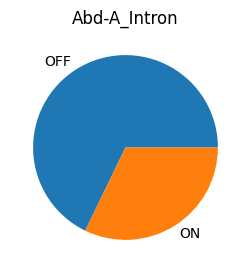

In [52]:
gene_names = transc_data.columns[1:].tolist()

fig, axs = plt.subplots(1, 1, figsize=(3, 3))

for i, gene in enumerate(gene_names):
    axs.pie(dataset[gene].value_counts(), labels=['OFF', 'ON'])
    axs.set_title(f"{gene}")


### Preprocess data

In [53]:
dataset[gene].value_counts()

Abd-A_Intron
0    590
1    280
Name: count, dtype: int64

##### Will use data from Abd-A gene, which is the gene yielding best results in paper (1641 OFF vs 653 ON)

In [54]:
dataset = pd.merge(dist_data, transc_data.iloc[:, :2], how='left', on='cellNumber').iloc[:, 1:]

X = dataset.iloc[:, :-1].to_numpy()
Y = dataset.iloc[:, -1].to_numpy()

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

### Create model - use grid search for hyperparameter tuning

In [55]:
# Define parameter search
param_grid = {
    'class_weight': [None, 'balanced'],
    'max_depth': [None, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [25, 50, 100, 150, 200, 300, 400, 500, 600],
}

In [56]:
# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [57]:
# Define model
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [58]:
# Initialize model with grid search
grid_search_random_forest_model = GridSearchCV(estimator=random_forest_model,
                                               param_grid = param_grid,
                                               cv=cv,
                                               scoring='f1_weighted',
                                               n_jobs=-1,
                                               verbose=2)

### Fit model - using entire parameter space

In [59]:
hist = grid_search_random_forest_model.fit(X_train, y_train)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END class_weight=None, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples

### Save hyperparameter tuning results

In [60]:
joblib.dump(grid_search_random_forest_model, "../results/random_forest_Mateo/gridsearch_results_random_forest_80.pkl")

grid_search_df = pd.DataFrame(grid_search_random_forest_model.cv_results_)
grid_search_df.to_csv("../results/random_forest_Mateo/gridsearch_results_random_forest_80.tsv", index=False, sep='\t')

In [61]:
print('The best hyperparameters found using 5-fold cross-validation are:')
print(grid_search_random_forest_model.best_params_)

with open('../results/random_forest_Mateo/hyperparams_80.txt', 'w') as f:
    f.write('The best hyperparameters found using 5-fold cross-validation are:\n')
    for key in grid_search_random_forest_model.best_params_:
        f.write(f"{key}: {grid_search_random_forest_model.best_params_[key]}\n")

The best hyperparameters found using 5-fold cross-validation are:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}


### Calculate predictions and plot metrics

In [62]:
# Select best model
best_model = grid_search_random_forest_model.best_estimator_

# Calculate predictions
y_pred = best_model.predict(X_test)
y_pred_scores = best_model.predict_proba(X_test)[:,1]

# Calculate predictions on training dataset
y_pred_train = best_model.predict(X_train)
y_pred_train_scores = best_model.predict_proba(X_train)[:,1]


In [63]:
# Classification report
class_report = classification_report(y_test, y_pred)

# Confusion matrics
conf_matrix = confusion_matrix(y_test, y_pred)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_scores)
auc = roc_auc_score(y_test, y_pred_scores)

# training ROC
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_train_scores)
auc_train = roc_auc_score(y_train, y_pred_train_scores)

In [64]:
# Print classification report
print(class_report)

with open('../results/random_forest_Mateo/classification_report_80.txt', 'w') as f:
    f.write(class_report)

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       118
           1       0.61      0.39      0.48        56

    accuracy                           0.72       174
   macro avg       0.68      0.64      0.65       174
weighted avg       0.71      0.72      0.70       174



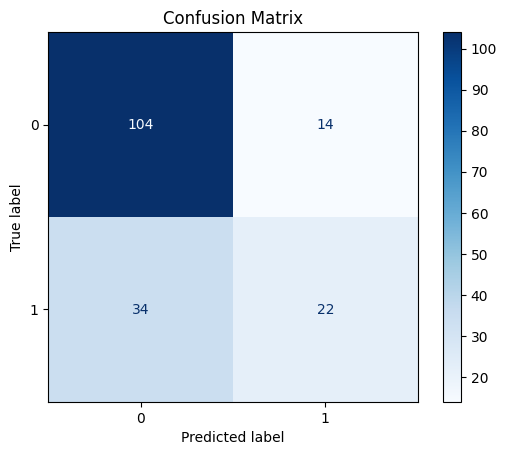

In [65]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_80.pdf', format='pdf')

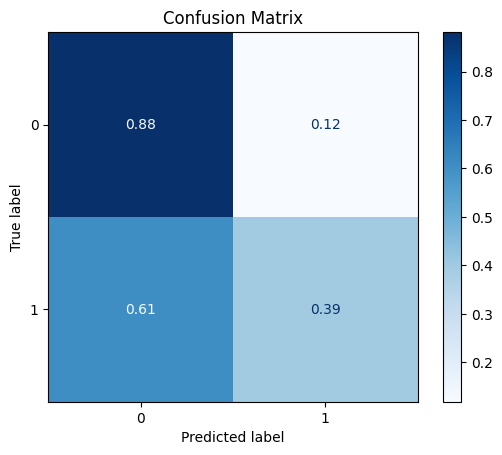

In [66]:
# Normalized confusion matrix
cm_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1)[:, None]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

disp.figure_.savefig('../results/random_forest_Mateo/confusion_matrix_normalized_80.pdf', format='pdf')

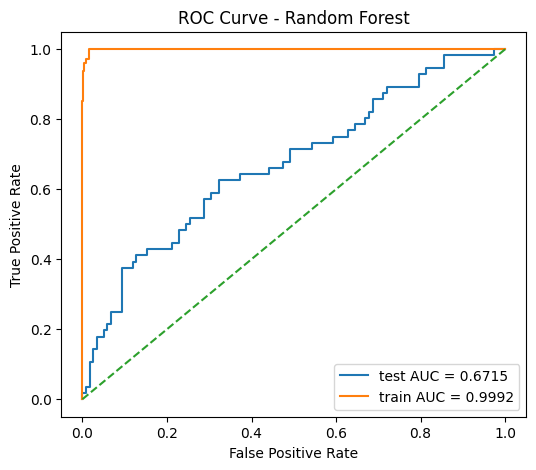

In [67]:
# ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"test AUC = {auc:.4f}")
plt.plot(fpr_train, tpr_train, label=f"train AUC = {auc_train:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig('../results/random_forest_Mateo/ROC_80.pdf', format='pdf')

In [68]:
# Get feture importances
n_feats = 20
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:n_feats]
features = dataset.columns[:-1]

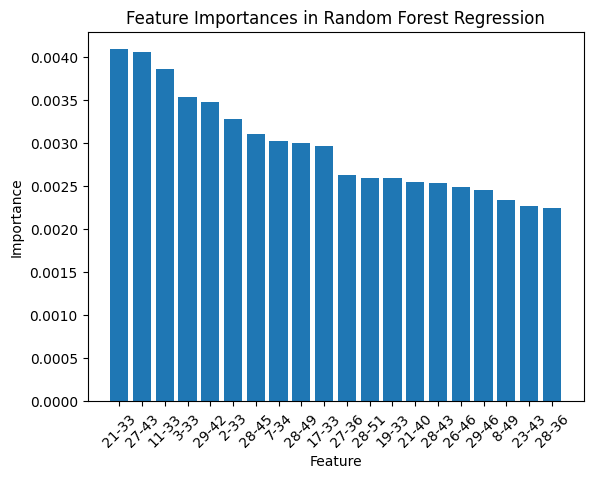

In [69]:
# Plot feature importances
plt.bar(range(n_feats), importances[indices],  align="center")
plt.xticks(range(n_feats), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

plt.savefig('../results/random_forest_Mateo/feature_importance_80.pdf', format='pdf')